# Loading and plotting campaign results

Loads `targeted_screen.csv` (the campaign matrix) and
`results/targeted_screen.ndjson` (what has actually been collected),
joins them on `Case_ID`, and gives a few reusable plotting functions
rather than one-off cells per figure.

Every column that describes *what a row is* (`Molecule`, `Basis`,
`Mapper`, `Method`, `Ansatz`, `Optimizer`, ...) comes from the matrix;
every column that describes *what happened* (`vqe_energy`,
`cost_history`, `wall_clock_s`, ...) comes from the results file. A row
with no matching result is kept, not dropped, so pending and
not-yet-submitted rows stay visible.

The energies plotted are the `energy` column: the **exact** energy of each
run's final state, recomputed by statevector from the parameters the run
ended on (`utils/_exact_energy.py`), wherever the result record carries
them. `vqe_energy` is the lowest noisy evaluation seen during the run, so
it sits a few shot-noise widths below the true energy -- far enough to
dip under FCI. It is used only for runs collected before the final
parameters were stored; `energy_source` says which a row has.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

REPO = pathlib.Path.cwd()
while not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
CAMPAIGN = REPO / "campaigns" / "ibm_tn-vqe_qesem"
RESULTS = CAMPAIGN / "results"

sys.path.insert(0, str(REPO / "utils"))
from _exact_energy import record_exact_energy  # noqa: E402 -- needs utils/ on sys.path


## Load and merge

In [2]:
matrix = pd.read_csv(CAMPAIGN / "targeted_screen.csv", dtype=str)

results_path = RESULTS / "targeted_screen.ndjson"
if results_path.exists() and results_path.stat().st_size:
    results = pd.read_json(results_path, lines=True)
    results["Case_ID"] = results["Case_ID"].astype(str)
else:
    results = pd.DataFrame(columns=["Case_ID"])


def _case_ids(name: str) -> set:
    """Case_IDs in results/targeted_screen.<name>.ndjson, or empty if the
    file doesn't exist yet -- pending/failed are only ever written once
    run_campaign.py or run_campaign_batch.ipynb has something to report."""
    path = RESULTS / f"targeted_screen.{name}.ndjson"
    if not path.exists() or not path.stat().st_size:
        return set()
    return set(pd.read_json(path, lines=True)["Case_ID"].astype(str))


# The exact energy of each run's final state, where the record carries the
# final parameters (runs collected before that was stored have none).
rows_by_case = matrix.set_index("Case_ID", drop=False).to_dict("index")
results["exact_energy"] = [
    record_exact_energy(record, rows_by_case[record["Case_ID"]])
    for record in results.to_dict("records")
] if len(results) else []

pending_ids = _case_ids("pending")
failed_ids = _case_ids("failed")

# Outcome columns only -- everything else (Molecule, Basis, Mapper, Method,
# Ansatz, Optimizer, ...) already lives in the matrix and would otherwise
# collide under pandas' _x/_y suffixes.
OUTCOME_COLUMNS = [
    "Case_ID", "Backend", "task_id", "vqe_energy", "exact_energy", "function_calls",
    "cost_history", "iteration_history", "iteration_boundaries",
    "wall_clock_s", "estimated_qpu_s", "collected_at",
]
df = matrix.merge(
    results[[c for c in OUTCOME_COLUMNS if c in results.columns]],
    on="Case_ID", how="left",
)

df["status"] = "not started"
df.loc[df["Case_ID"].isin(pending_ids), "status"] = "pending"
df.loc[df["Case_ID"].isin(failed_ids), "status"] = "failed"
df.loc[df["vqe_energy"].notna(), "status"] = "collected"

# What the plots use: the exact energy of the final state where there is
# one, otherwise vqe_energy -- the lowest noisy evaluation, which sits a few
# shot-noise widths below the true energy.
if "exact_energy" not in df:
    df["exact_energy"] = float("nan")
df["energy"] = df["exact_energy"].astype(float).fillna(df["vqe_energy"])
df["energy_source"] = df["exact_energy"].notna().map({True: "exact", False: "vqe_energy"})
df.loc[df["vqe_energy"].isna(), "energy_source"] = None

print(f"{len(df)} rows in the campaign")
print(df["status"].value_counts().to_string())
print(df["energy_source"].value_counts().to_string())


46 rows in the campaign
status
collected    46


In [3]:
# Status by axis -- which combinations still need running.
df.groupby(["Method", "Ansatz"])["status"].value_counts().unstack(fill_value=0)


status                 collected
Method Ansatz                   
TN     RealAmplitudes          6
TN-VQE RealAmplitudes          6
       tUPS                    2
VQE    RealAmplitudes         11
       UCCSD                   5
       rzryrz                  7
       tUPS                    9

## Convergence curves

`plot_convergence` takes the same kind of filter the exploratory notebook
used (`Molecule="H2"`, `Mapper="JW"`, ...), but as keyword arguments
rather than a dict literal, and plots every collected row that matches --
labelling each line by whatever *isn't* fixed, so the legend reads as the
comparison rather than repeating what's already in the title.

In [4]:
def plot_convergence(df, ax=None, **filters):
    """cost_history against evaluation index for every collected row
    matching `filters` (column=value keyword pairs, e.g. Mapper="JW").
    """
    subset = df
    for column, value in filters.items():
        subset = subset[subset[column] == str(value)]
    subset = subset[subset["cost_history"].notna()]
    if subset.empty:
        print(f"no collected rows match {filters}")
        return None

    label_columns = [c for c in
        ["Case_ID", "Method", "Ansatz", "Mapper", "Optimizer",
         "Ansatz_Reps", "TN_Layers_Network"]
        if c not in filters]

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 8))
    for _, row in subset.iterrows():
        label = ", ".join(
            f"{row[c]}" for c in label_columns if str(row[c]).strip()
        )
        ax.plot(row["iteration_boundaries"],row["iteration_history"], label=label or row["Case_ID"], alpha=0.8)
        #ax.plot(row["cost_history"], label=label or row["Case_ID"], alpha=0.8)
    ax.set_xlabel("cost-function evaluation")
    ax.set_ylabel("energy (Ha)")
    ax.legend(fontsize=8)
    return ax


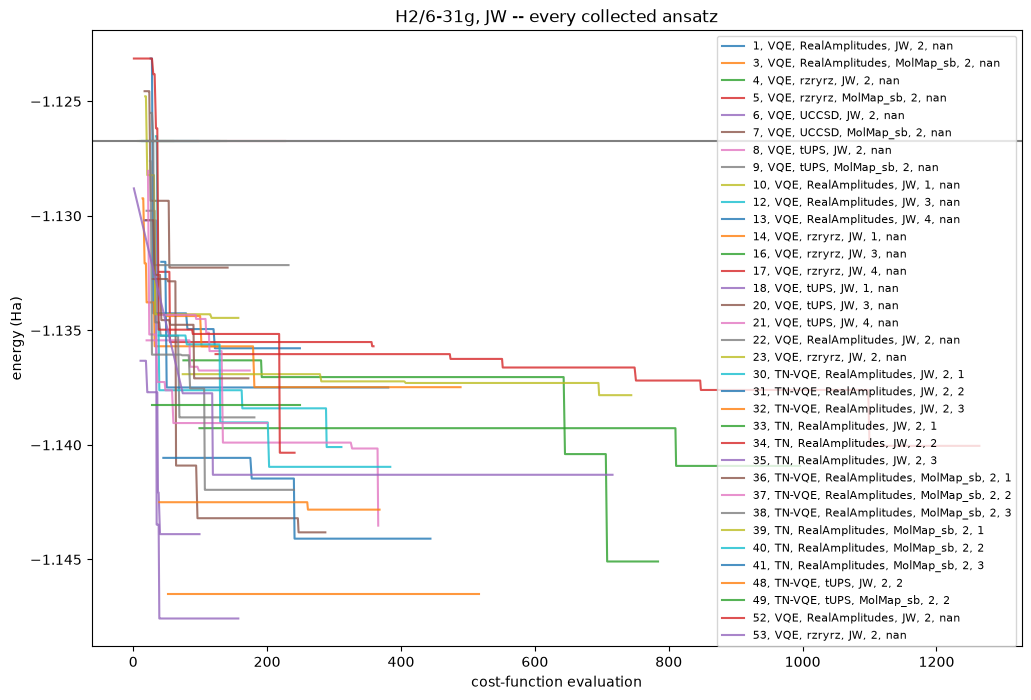

In [5]:
plot_convergence(df, Molecule="H2", Basis="6-31g", Optimizer='COBYLA')
plt.title("H2/6-31g, JW -- every collected ansatz")
plt.axhline(-1.126733,color='gray')
plt.show()


## Method comparison

`plot_method_comparison` finds every (`Molecule`, `Basis`, `Mapper`,
`Ansatz`) group that has more than one `Method` collected -- the
comparison this campaign exists to make -- and plots their final
energies side by side. A group with only one `Method` collected so far
is skipped rather than plotted alone, since there is nothing to compare
it against yet.

In [6]:
def plot_method_comparison(df, group_cols=("Molecule", "Mapper", "Ansatz")):
    collected = df[df["energy"].notna()].copy()
    if collected.empty:
        print("nothing collected yet")
        return None

    collected["group"] = collected[list(group_cols)].agg("/".join, axis=1)
    counts = collected.groupby("group")["Method"].nunique()
    worth_plotting = counts[counts > 1].index
    collected = collected[collected["group"].isin(worth_plotting)]
    if collected.empty:
        print("no group has more than one Method collected yet")
        return None

    fig, ax = plt.subplots(figsize=(12, 6))
    markers = {"VQE": "o", "TN-VQE": "s", "TN": "^"}
    for method, sub in collected.groupby("Method"):
        ax.scatter(sub["group"], sub["energy"], label=method,
                   marker=markers.get(method, "x"), s=60)
    ax.set_ylabel("energy (Ha)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    fig.tight_layout()
    return ax


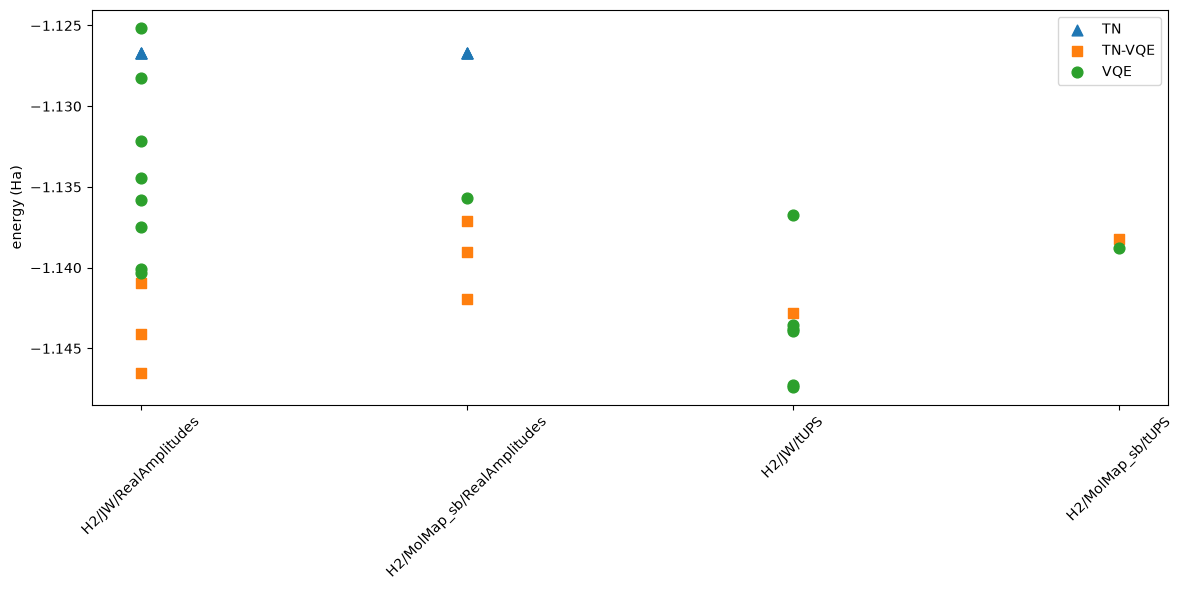

In [7]:
plot_method_comparison(df)
plt.show()


## TN-VQE across TN layers vs VQE

The mode × TN-layers axis: RealAmplitudes at the baseline reps on
H2/6-31g, COBYLA, `TN_Layers_Network` = 1, 2, 3 for `TN-VQE` and the
classical-only `TN` control, against the plain `VQE` row at the same
settings. One column per mapper.

Top row: the energy of each run against its layer count. VQE has no
layer count, so it is drawn as a horizontal line. Energies are the
`energy` column (see the top of the notebook). Bottom row: the
convergence curves (`iteration_history`, best so far, still noisy).

In [23]:
def plot_tn_layers_vs_vqe(df, molecule="H2", basis="6-31g", ansatz="RealAmplitudes",
                          reps="2", optimizer="COBYLA", hf=None):
    """Energy against TN_Layers_Network for TN-VQE and TN, with the matching
    VQE row as a reference line, one column per mapper; convergence curves
    underneath. Only rows with the family's default entanglement are used,
    so the entangler-topology axis doesn't leak in."""
    subset = df[
        (df["Molecule"] == molecule) & (df["Basis"] == basis)
        & (df["Ansatz"] == ansatz) & (df["Ansatz_Reps"] == str(reps))
        & (df["Optimizer"] == optimizer) & df["Entanglement"].isna()
        & df["energy"].notna()
    ]
    mappers = sorted(subset["Mapper"].unique())
    if not mappers:
        print("nothing collected for this comparison yet")
        return None

    fig, axes = plt.subplots(2, len(mappers), figsize=(7 * len(mappers), 9),
                             squeeze=False, sharey=True)
    colors = {"VQE": "C0", "TN-VQE": "C1", "TN": "C2"}
    markers = {"TN-VQE": "s", "TN": "^"}

    for col, mapper in enumerate(mappers):
        top, bottom = axes[0, col], axes[1, col]
        rows = subset[subset["Mapper"] == mapper]

        for _, vqe in rows[rows["Method"] == "VQE"].iterrows():
            top.axhline(vqe["energy"], color=colors["VQE"], ls="--",
                        label=f"VQE (case {vqe['Case_ID']})")

        for method in ("TN-VQE", "TN"):
            sub = rows[rows["Method"] == method].copy()
            if sub.empty:
                continue
            sub["layers"] = sub["TN_Layers_Network"].astype(int)
            sub = sub.sort_values("layers")
            top.plot(sub["layers"], sub["energy"], marker=markers[method],
                     color=colors[method], label=method)

        for _, r in rows.iterrows():
            layers = r["TN_Layers_Network"]
            label = r["Method"] + (f", {layers} layer{'s' if layers != '1' else ''}" if isinstance(layers, str) else "")
            style = {"VQE": "-", "TN-VQE": "-", "TN": "--"}[r["Method"]]
            bottom.plot(r["iteration_boundaries"], r["iteration_history"],
            #bottom.plot(r["cost_history"],
                        ls=style, color=colors[r["Method"]],
                        alpha=0.4 + 0.2 * (int(layers) if isinstance(layers, str) else 3),
                        label=label)

        for ax in (top, bottom):
            if hf is not None:
                ax.axhline(hf, color="gray", lw=0.8, label="HF")
            ax.set_ylabel("energy (Ha)")
            ax.legend(fontsize=8)
        top.set_title(f"{molecule}/{basis}, {mapper}: {ansatz} reps={reps}, {optimizer}")
        top.set_xlabel("TN_Layers_Network")
        top.set_xticks(sorted(subset["TN_Layers_Network"].dropna().astype(int).unique()))
        bottom.set_xlabel("cost-function evaluation")

    fig.tight_layout()
    return axes

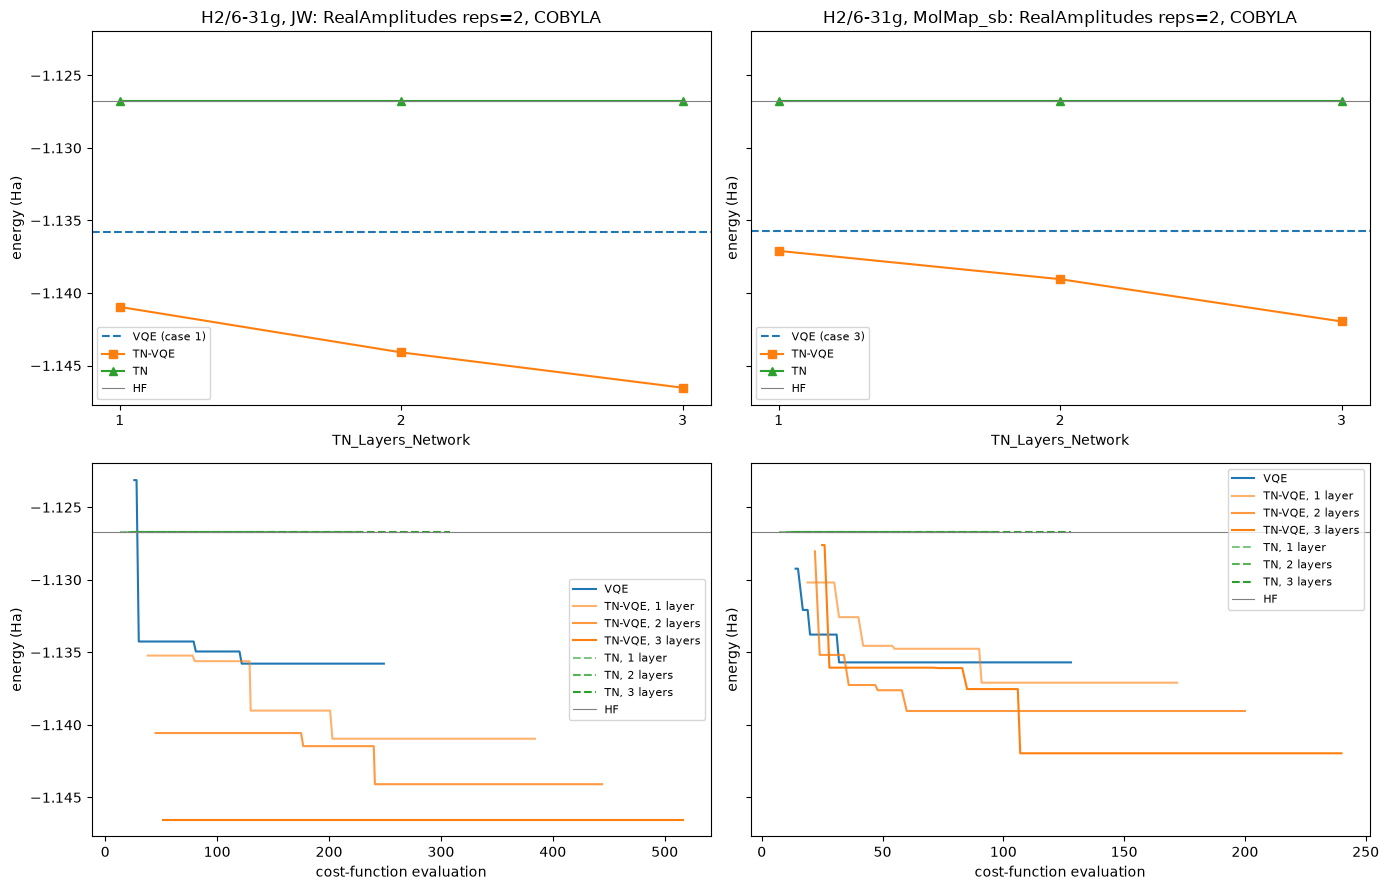

In [24]:
plot_tn_layers_vs_vqe(df, hf=-1.1267333176928163)
plt.show()


## Ansatz comparison

Plain VQE with one optimizer, each family at its default entanglement:

- **Left:** every ansatz at its default depth — 2 reps (tUPS: 2 layers),
  except UCCSD, which is a single layer — one marker per mapper: the
  mapper axis.
- **Middle:** energy against reps (tUPS: layers) under JW — the reps
  axis. UCCSD has no reps sweep, so it appears as a single point at 1.
- **Right:** convergence curves at the same default depths, one colour
  per ansatz, solid for JW and dashed for MolMap_sb.

Energies are the `energy` column (see the top of the notebook). Where
that falls back to `vqe_energy`, a point slightly under FCI is shot
noise, not a violation of the variational bound.

In [ ]:
ANSATZ_ORDER = ["RealAmplitudes", "rzryrz", "UCCSD", "tUPS"]
ANSATZ_COLORS = {a: f"C{i}" for i, a in enumerate(ANSATZ_ORDER)}
MAPPER_STYLE = {"JW": dict(marker="o", ls="-"), "MolMap_sb": dict(marker="s", ls="--")}


def plot_ansatz_comparison(df, molecule="H2", basis="6-31g", optimizer="COBYLA",
                           hf=None, fci=None):
    """Plain-VQE energies per ansatz: by mapper at 2 reps, against reps
    under JW, and the convergence curves at 2 reps."""
    subset = df[
        (df["Molecule"] == molecule) & (df["Basis"] == basis)
        & (df["Method"] == "VQE") & (df["Optimizer"] == optimizer)
        & df["Entanglement"].isna() & df["energy"].notna()
    ]
    if subset.empty:
        print("nothing collected for this comparison yet")
        return None
    ansatze = [a for a in ANSATZ_ORDER if a in set(subset["Ansatz"])]
    # UCCSD is a single layer (Ansatz_Reps = 1); every other family's
    # default is 2.
    at_2 = subset[(subset["Ansatz_Reps"] == "2") | (subset["Ansatz"] == "UCCSD")]

    fig, (left, middle, right) = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

    # Left: mapper axis at 2 reps, markers offset so the two mappers don't overlap.
    for offset, (mapper, style) in zip((-0.12, 0.12), MAPPER_STYLE.items()):
        rows = at_2[at_2["Mapper"] == mapper].set_index("Ansatz")
        xs = [i + offset for i, a in enumerate(ansatze) if a in rows.index]
        ys = [rows.loc[a, "energy"] for a in ansatze if a in rows.index]
        left.scatter(xs, ys, marker=style["marker"], s=70,
                     c=[ANSATZ_COLORS[a] for a in ansatze if a in rows.index])
        # Colour means ansatz here, so the mapper legend entry is neutral.
        left.scatter([], [], marker=style["marker"], s=70, color="gray", label=mapper)
    left.set_xticks(range(len(ansatze)), ansatze)
    left.set_title(f"{molecule}/{basis}, VQE, {optimizer}: default depth, by mapper")
    left.set_ylabel("energy (Ha)")

    # Middle: reps axis under JW.
    jw = subset[subset["Mapper"] == "JW"].copy()
    jw["reps"] = jw["Ansatz_Reps"].astype(int)
    for ansatz in ansatze:
        rows = jw[jw["Ansatz"] == ansatz].sort_values("reps")
        params = ", ".join(f"{r}:{n}" for r, n in zip(rows["reps"], rows["Num_Opt_Params_Phi"]))
        middle.plot(rows["reps"], rows["energy"], marker="o",
                    color=ANSATZ_COLORS[ansatz], label=f"{ansatz} (reps:params {params})")
    middle.set_xticks(sorted(jw["reps"].unique()))
    middle.set_xlabel("Ansatz_Reps (tUPS: layers)")
    middle.set_title("JW, by reps")

    # Right: convergence at 2 reps.
    for _, r in at_2.iterrows():
        style = MAPPER_STYLE.get(r["Mapper"], {})
        right.plot(r["iteration_boundaries"], r["iteration_history"],
                   ls=style.get("ls", "-"), color=ANSATZ_COLORS.get(r["Ansatz"], "k"),
                   label=f"{r['Ansatz']}, {r['Mapper']} (case {r['Case_ID']})")
    right.set_xlabel("cost-function evaluation")
    right.set_title("convergence at default depth")

    for ax in (left, middle, right):
        if hf is not None:
            ax.axhline(hf, color="gray", lw=0.8, label="HF")
        if fci is not None:
            ax.axhline(fci, color="black", lw=0.8, ls=":", label="FCI")
        ax.legend(fontsize=8)
    fig.tight_layout()
    return fig

In [ ]:
# FCI: lowest eigenvalue of hamiltonian_data/h2_6-31G_JW.json in the 2-electron sector.
plot_ansatz_comparison(df, hf=-1.1267333176928163, fci=-1.151683)
plt.show()

## Entanglement comparison

The entangler-topology axis: each hardware-efficient family under
`reverse_linear`, `sca` and `full`, everything else fixed (H2/6-31g, JW,
VQE, COBYLA, 2 reps). The defaults are `reverse_linear` for
RealAmplitudes and `sca` for rzryrz; an empty `Entanglement` column
means the default.

| Ansatz | `reverse_linear` | `sca` | `full` |
|---|---|---|---|
| RealAmplitudes | case 1 (default) | case 52 | case 22 |
| rzryrz | case 53 | case 4 (default) | case 23 |

- **Left:** final energy per ansatz, one marker per topology.
- **Right:** convergence curves, one colour per ansatz, one line style
  per topology.

In [ ]:
# Each family's default topology, as _ansatz_builders.DEFAULT_ENTANGLEMENT defines it.
DEFAULT_TOPOLOGY = {"RealAmplitudes": "reverse_linear", "rzryrz": "sca"}
TOPOLOGY_ORDER = ["reverse_linear", "linear", "sca", "circular", "full"]


def plot_entanglement_comparison(df, molecule="H2", basis="6-31g", mapper="JW",
                                 reps="2", optimizer="COBYLA", hf=None, fci=None):
    """Every collected topology, per hardware-efficient ansatz that has more
    than one; the family's default is marked in the x-axis label."""
    subset = df[
        (df["Molecule"] == molecule) & (df["Basis"] == basis)
        & (df["Mapper"] == mapper) & (df["Method"] == "VQE")
        & (df["Ansatz_Reps"] == str(reps)) & (df["Optimizer"] == optimizer)
        & df["energy"].notna()
    ].copy()
    subset = subset[subset["Ansatz"].isin(DEFAULT_TOPOLOGY)]
    subset["topology"] = subset["Entanglement"].fillna(subset["Ansatz"].map(DEFAULT_TOPOLOGY))
    ansatze = [a for a in ANSATZ_ORDER
               if subset.loc[subset["Ansatz"] == a, "topology"].nunique() > 1]
    subset = subset[subset["Ansatz"].isin(ansatze)]
    if subset.empty:
        print("no ansatz has an alternate topology collected yet")
        return None

    topologies = [t for t in TOPOLOGY_ORDER if t in set(subset["topology"])]
    markers = dict(zip(topologies, ["o", "s", "D", "^", "v"]))
    linestyles = dict(zip(topologies, ["-", "--", ":", "-.", (0, (5, 1))]))

    fig, (left, right) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    offsets = dict(zip(topologies, [(i - (len(topologies) - 1) / 2) * 0.15
                                    for i in range(len(topologies))]))
    for topology in topologies:
        rows = subset[subset["topology"] == topology].set_index("Ansatz")
        present = [a for a in ansatze if a in rows.index]
        left.scatter([ansatze.index(a) + offsets[topology] for a in present],
                     [rows.loc[a, "energy"] for a in present],
                     marker=markers[topology], s=70,
                     c=[ANSATZ_COLORS[a] for a in present])
        # Colour means ansatz here, so the topology legend entry is neutral.
        left.scatter([], [], marker=markers[topology], s=70, color="gray", label=topology)
    left.set_xticks(range(len(ansatze)),
                    [f"{a}\n(default: {DEFAULT_TOPOLOGY.get(a, '?')})" for a in ansatze])
    left.set_title(f"{molecule}/{basis}, {mapper}, VQE, {optimizer}, {reps} reps: by topology")
    left.set_ylabel("energy (Ha)")

    for _, r in subset.iterrows():
        right.plot(r["iteration_boundaries"], r["iteration_history"],
                   ls=linestyles[r["topology"]], color=ANSATZ_COLORS[r["Ansatz"]],
                   label=f"{r['Ansatz']}, {r['topology']} (case {r['Case_ID']})")
    right.set_xlabel("cost-function evaluation")
    right.set_title("convergence")

    for ax in (left, right):
        if hf is not None:
            ax.axhline(hf, color="gray", lw=0.8, label="HF")
        if fci is not None:
            ax.axhline(fci, color="black", lw=0.8, ls=":", label="FCI")
        ax.legend(fontsize=8)
    fig.tight_layout()
    return fig

In [ ]:
plot_entanglement_comparison(df, hf=-1.1267333176928163, fci=-1.151683)
plt.show()

## Classical reference energies

This campaign's own known Hartree-Fock references, established and
verified (zero-phi energy against the pinned Hamiltonian) throughout
`regenerate_spinblock_mol_map.py` and the campaign README:

| Cell | HF energy (Ha) |
|---|---:|
| H2/6-31g | -1.1267333176928163 |
| H2O/6-31g, CAS(4,4) | -75.98399756962218 |

These are Hartree-Fock, not FCI: a useful sanity floor (every collected
VQE energy should fall below it, since VQE recovers correlation energy
HF misses), not a correlation-energy target. For a real FCI/CCSD
reference at one of this campaign's own geometries, adapt
`utils/classical_reference_energies.py`'s PySCF calls to the
`Geometry`/`Basis`/`Active_Electrons`/`Active_Orbitals` columns of the
row you care about.

In [ ]:
HF_REFERENCE = {
    ("H2", "6-31g"): -1.1267333176928163,
    ("H2O", "6-31g"): -75.98399756962218,
}

collected = df[df["energy"].notna()].copy()
collected["hf_reference"] = collected.apply(
    lambda r: HF_REFERENCE.get((r["Molecule"], r["Basis"])), axis=1
)
collected["below_hf"] = collected["energy"] < collected["hf_reference"]
collected[["Case_ID", "Molecule", "Basis", "Mapper", "Method", "Ansatz",
           "energy", "energy_source", "vqe_energy", "hf_reference", "below_hf"]]
